# 07 — Classification Training

Trains one or all 5 folds of a classification experiment. Everything — model, loss,
optimizer, scheduler — is specified by `RECIPE` in Cell 3. Fold control is in Cell 5.

**Training always uses GT masks** for ROI extraction. Predicted masks are only used
at test time (Eval B, NB08).

**Outputs per fold** (synced to Drive by Cell 11):

```
outputs/
├── checkpoints/classification/<dataset>/<exp>/fold_k/
│   ├── best.ckpt
│   ├── best_model.pt
│   └── experiment_config.json
├── logs/classification/<dataset>/<exp>/fold_k/metrics.csv
├── tables/classification/<dataset>/<exp>/<exp>_train_summary.csv
└── figures/classification/<dataset>/<exp>/
    ├── fold_k/history_fold_k.png
    └── training_curves_overlay.png
```

**Runtime:** GPU (T4 or better). One fold typically takes 15–30 minutes.

## Cell 1 — Install dependencies

In [1]:
%pip install -q pytorch-lightning segmentation-models-pytorch albumentations opencv-python-headless timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 47.9 MB/s eta 0:00:00


## Cell 2 — Bootstrap: Drive + repo + local SSD scratch

In [2]:
import os, sys

if not os.path.exists('/content/senior_project'):
    from google.colab import userdata
    try:
        token = userdata.get('GITHUB_TOKEN')
    except Exception:
        token = None
    url = 'https://github.com/salemaker47/senior_project.git'
    if token:
        url = url.replace('https://', f'https://{token}@', 1)
    os.system(f'git clone {url} /content/senior_project')
if '/content/senior_project' not in sys.path:
    sys.path.insert(0, '/content/senior_project')

from src.notebook_setup import setup_environment

DRIVE_ROOT, REPO_ROOT = setup_environment(
    repo_url='https://github.com/salemaker47/senior_project.git',
)
print(f'DRIVE_ROOT: {DRIVE_ROOT}')
print(f'REPO_ROOT:  {REPO_ROOT}')

Mounted at /content/drive
DRIVE_ROOT: /content/drive/MyDrive/Senior_Project
REPO_ROOT:  /content/senior_project


In [3]:
import os, psutil
print(f'CPU count: {os.cpu_count()}')
print(f'RAM total: {psutil.virtual_memory().total / 1e9:.1f} GB')
print(f'RAM avail: {psutil.virtual_memory().available / 1e9:.1f} GB')

CPU count: 8
RAM total: 54.8 GB
RAM avail: 52.8 GB


## Cell 3 — EXPERIMENT config (the single source of truth)

Edit `RECIPE`, `DATASET`, and `SPLIT_SCHEME` to define a run.
Hyperparameters for each recipe live in `configs/cls/reference_experiments.py`.

**Knobs:**
- `RECIPE`: one of `REFERENCE_RECIPES` (printed below)
- `DATASET`: `"figshare"` (only figshare supports multiclass classification)
- `SPLIT_SCHEME`: `"image_level"` or `"patient_level"`

Fold control is in Cell 5.

In [4]:
from configs.cls.reference_experiments import get_experiment, REFERENCE_RECIPES

# ----- The 3 axes of a run -----
RECIPE       = 'cls04_vit'   # one of REFERENCE_RECIPES
DATASET      = 'figshare'         # only figshare for classification
SPLIT_SCHEME = 'image_level'      # 'image_level' | 'patient_level'

EXPERIMENT = get_experiment(
    RECIPE, dataset=DATASET, split_scheme=SPLIT_SCHEME, fold=1,
)

# ----- Sanity asserts ---------------------------------------------------------
assert EXPERIMENT['task'] == 'classification'
assert EXPERIMENT['dataset'] in ('figshare',), \
    f'Classification only supported on figshare, got {EXPERIMENT["dataset"]!r}'
assert EXPERIMENT['split_scheme'] in ('image_level', 'patient_level')

print(f"EXPERIMENT: {EXPERIMENT['name']}")
print(f"  recipe:       {EXPERIMENT['recipe']}")
print(f"  dataset:      {EXPERIMENT['dataset']}")
print(f"  split_scheme: {EXPERIMENT['split_scheme']}")
print(f"  model:        {EXPERIMENT['model_name']}")
print(f"  loss:         {EXPERIMENT['loss_name']}  kwargs={EXPERIMENT['loss_kwargs']}")
print(f"  batch_size:   {EXPERIMENT['batch_size']}    patch_size: {EXPERIMENT['patch_size']}")
print(f"  lr:           {EXPERIMENT['optimizer_kwargs']['lr']}")
print(f"  monitor:      {EXPERIMENT['monitor']}  (patience={EXPERIMENT['patience']})")
print(f"\nAvailable recipes: {REFERENCE_RECIPES}")

EXPERIMENT: cls04_vit_image_level
  recipe:       cls04_vit
  dataset:      figshare
  split_scheme: image_level
  model:        vit_small_patch16_224
  loss:         cross_entropy_smooth  kwargs={'label_smoothing': 0.1, 'class_weights': None}
  batch_size:   16    patch_size: 224
  lr:           0.0001
  monitor:      val_macro_f1  (patience=10)

Available recipes: ['cls01_resnet50', 'cls02_effb0', 'cls03_effb4', 'cls04_vit']


## Cell 4 — Seed + copy data to local SSD

In [5]:
from src.train_utils    import set_global_seed
from src.notebook_setup import copy_to_local

set_global_seed(EXPERIMENT['seed'])
LOCAL_ROOT = copy_to_local(DRIVE_ROOT, datasets=[EXPERIMENT['dataset']])
print(f'LOCAL_ROOT: {LOCAL_ROOT}')

INFO:lightning_fabric.utilities.seed:Seed set to 42


[copy_to_local] copying zip figshare.zip (110 MB) ...
[copy_to_local] extracting to /content/Senior_Project_local/data ...
[copy_to_local] extracted figshare
[copy_to_local] cwd is now /content/Senior_Project_local
LOCAL_ROOT: /content/Senior_Project_local


## Cell 5 — Fold control

In [6]:
# ----- Fold control --------------------------------------------------------
FOLD_TO_RUN   = 1       # used when RUN_ALL_FOLDS = False
RUN_ALL_FOLDS = True   # flip to True after fold 1 looks good
# ---------------------------------------------------------------------------

folds_to_run = list(range(1, 6)) if RUN_ALL_FOLDS else [FOLD_TO_RUN]
print(f'folds_to_run = {folds_to_run}')
print(f'(experiment: {EXPERIMENT["name"]} on {EXPERIMENT["dataset"]})')

folds_to_run = [1, 2, 3, 4, 5]
(experiment: cls04_vit_image_level on figshare)


## Cell 6 — train_one_fold

In [7]:
import time
import torch
import pandas as pd
from pytorch_lightning.callbacks import ModelCheckpoint

from src.data_utils              import load_metadata, validate_metadata
from src.cls_data_utils          import build_dataloaders_cls
from src.cls_models              import build_cls_model, count_parameters
from src.cls_losses              import get_cls_loss
from src.cls_lightning_module    import BrainTumorClsModule
from src.train_utils             import (
    build_callbacks, build_trainer, TrainingTimingCallback,
    gather_repro_metadata, export_plain_state_dict, consolidate_metrics_csv,
)
from src.file_utils              import save_json, experiment_paths, fold_split_csv_paths


def train_one_fold(fold: int, experiment: dict) -> dict:
    """
    Train a single classification fold end-to-end using GT masks for ROI extraction.

    Writes:
        outputs/checkpoints/classification/<dataset>/<exp>/fold_<k>/best.ckpt
                                                                    best_model.pt
                                                                    experiment_config.json
        outputs/logs/classification/<dataset>/<exp>/fold_<k>/metrics.csv
    """
    experiment = dict(experiment)   # safe copy so the outer EXPERIMENT is not mutated
    experiment['fold'] = fold

    paths = experiment_paths(
        LOCAL_ROOT,
        task=experiment['task'], dataset=experiment['dataset'],
        experiment_name=experiment['name'], fold=fold,
    )
    csv_paths = fold_split_csv_paths(
        LOCAL_ROOT,
        dataset=experiment['dataset'],
        scheme=experiment['split_scheme'],
        fold=fold,
    )

    # ----- Data -----
    train_df = load_metadata(csv_paths['train']); validate_metadata(train_df)
    val_df   = load_metadata(csv_paths['val']);   validate_metadata(val_df)
    print(f'  fold {fold}: train={len(train_df):>5} imgs / '
          f'{train_df["patient_id"].nunique():>3} pts | '
          f'val={len(val_df):>5} imgs / {val_df["patient_id"].nunique():>3} pts')

    train_loader, val_loader = build_dataloaders_cls(
        train_df=train_df, val_df=val_df, project_root=LOCAL_ROOT,
        batch_size=experiment['batch_size'],
        num_workers=experiment.get('num_workers', 2),
        image_size=experiment['patch_size'],
        padding_frac=experiment['padding_frac'],
        seed=experiment['seed'],
    )

    # ----- Model + loss + module -----
    model = build_cls_model(
        name=experiment['model_name'],
        num_classes=experiment['num_classes'],
        pretrained=experiment.get('pretrained', True),
    )
    params_count = count_parameters(model)
    loss_fn = get_cls_loss(experiment['loss_name'], **experiment.get('loss_kwargs', {}))

    pl_module = BrainTumorClsModule(
        model=model, loss_fn=loss_fn,
        num_classes=experiment['num_classes'],
        optimizer_name=experiment['optimizer_name'],
        optimizer_kwargs=experiment['optimizer_kwargs'],
        scheduler_name=experiment.get('scheduler_name'),
        scheduler_kwargs=experiment.get('scheduler_kwargs', {}),
        scheduler_monitor=experiment.get('monitor', 'val_macro_f1'),
    )

    # ----- Trainer + callbacks -----
    callbacks = build_callbacks(
        ckpt_dir=paths['checkpoints'],
        monitor=experiment['monitor'],
        mode=experiment['monitor_mode'],
        patience=experiment['patience'],
        epoch_summary_keys=('train_loss', 'val_loss', 'val_macro_f1'),
    )
    trainer = build_trainer(
        callbacks=callbacks, log_dir=paths['logs'],
        max_epochs=experiment['max_epochs'], precision='auto',
    )

    # ----- Train -----
    print(f'  fold {fold}: training start  (max_epochs={experiment["max_epochs"]})')
    t0 = time.time()
    trainer.fit(pl_module, train_loader, val_loader)
    train_seconds = time.time() - t0
    print(f'  fold {fold}: training done in {train_seconds/60:.1f} min')

    # ----- Collect training meta -----
    ckpt_cb   = next(c for c in callbacks if isinstance(c, ModelCheckpoint))
    timing_cb = next(c for c in callbacks if isinstance(c, TrainingTimingCallback))
    best_ckpt = ckpt_cb.best_model_path
    best_blob = torch.load(best_ckpt, map_location='cpu', weights_only=False)

    training_meta = {
        'fold':                 fold,
        'best_epoch':           int(best_blob.get('epoch', -1)),
        'best_val_macro_f1':    float(ckpt_cb.best_model_score) if ckpt_cb.best_model_score is not None else None,
        'total_epochs_trained': int(trainer.current_epoch + 1),
        'train_seconds':        train_seconds,
        'params_count':         int(params_count),
        'peak_gpu_mem_mb':      timing_cb.peak_gpu_mem_mb,
        'best_ckpt_path':       best_ckpt,
    }

    # ----- Export plain .pt -----
    export_plain_state_dict(
        lightning_ckpt_path=best_ckpt,
        out_pt_path=paths['best_model'],
        extra_meta={
            'experiment': experiment,
            'model_name': experiment['model_name'],
        },
    )

    # ----- Save experiment_config.json -----
    save_json(
        {
            'EXPERIMENT':     experiment,
            'training_meta':  training_meta,
            'repro_metadata': gather_repro_metadata(repo_root=REPO_ROOT),
        },
        paths['experiment_config_json'],
    )

    metrics_csv = paths['logs'] / 'metrics.csv'
    history_df  = consolidate_metrics_csv(metrics_csv) if metrics_csv.exists() else None

    return {
        **training_meta,
        'history': history_df,
        'paths':   paths,
    }

print('train_one_fold defined.')

train_one_fold defined.


## Cell 7 — Training loop

In [8]:
import gc
import torch

results = {}
for fold in folds_to_run:
    print(f"\n{'='*70}")
    print(f"  FOLD {fold}  ({EXPERIMENT['name']} on {EXPERIMENT['dataset']})")
    print(f"{'='*70}")
    try:
        results[fold] = train_one_fold(fold, EXPERIMENT)
        bf1 = results[fold]['best_val_macro_f1']
        print(f"  ✓ fold {fold} complete: best_val_macro_f1 = {'%.4f' % bf1 if bf1 is not None else 'n/a'}")
    except Exception as e:
        print(f"  ✗ fold {fold} FAILED: {type(e).__name__}: {e}")
        print(f"     to retry: set FOLD_TO_RUN={fold}, RUN_ALL_FOLDS=False in Cell 5, re-run from Cell 6")
        import traceback; traceback.print_exc()
        results[fold] = {'error': str(e), 'fold': fold}
    finally:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()

print(f"\n{'='*70}")
print(f"  RUN COMPLETE — folds attempted: {list(results.keys())}")
print(f"  failed folds: {[k for k, v in results.items() if 'error' in v]}")
print(f"{'='*70}")


  FOLD 1  (cls04_vit_image_level on figshare)
  fold 1: train= 2083 imgs / 230 pts | val=  368 imgs / 167 pts


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  fold 1: training start  (max_epochs=100)


...

[15:55:33] E 31/99 | train_loss=0.3056 | val_loss=0.3444 | val_macro_f1=0.9749

[15:55:42] E 32/99 | train_loss=0.2991 | val_loss=0.3880 | val_macro_f1=0.9643

[15:55:51] E 33/99 | train_loss=0.3190 | val_loss=0.3463 | val_macro_f1=0.9450

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_macro_f1 did not improve in the last 10 records. Best score: 0.984. Signaling Trainer to stop.


  fold 5: training done in 5.4 min
  ✓ fold 5 complete: best_val_macro_f1 = 0.9845

  RUN COMPLETE — folds attempted: [1, 2, 3, 4, 5]
  failed folds: []


## Cell 8 — Per-fold history plots (train_loss / val_macro_f1)

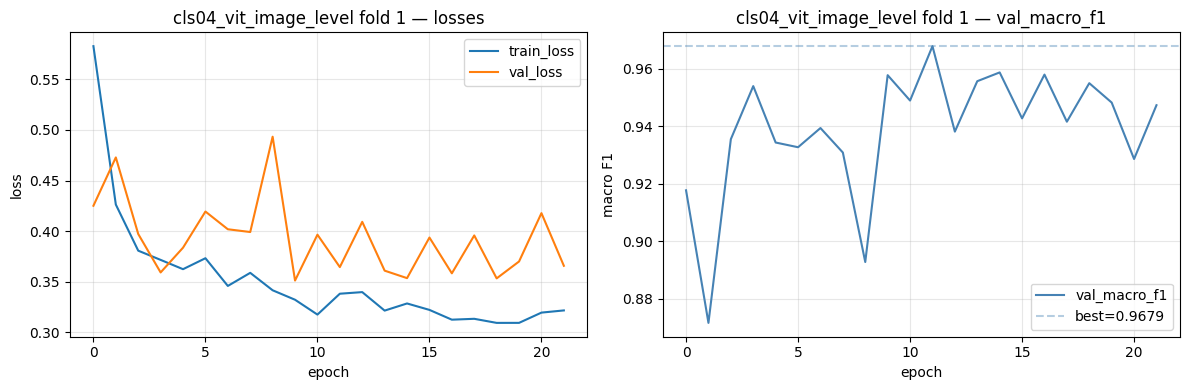

  saved /content/Senior_Project_local/outputs/figures/classification/figshare/cls04_vit_image_level/fold_1/history_fold_1.png


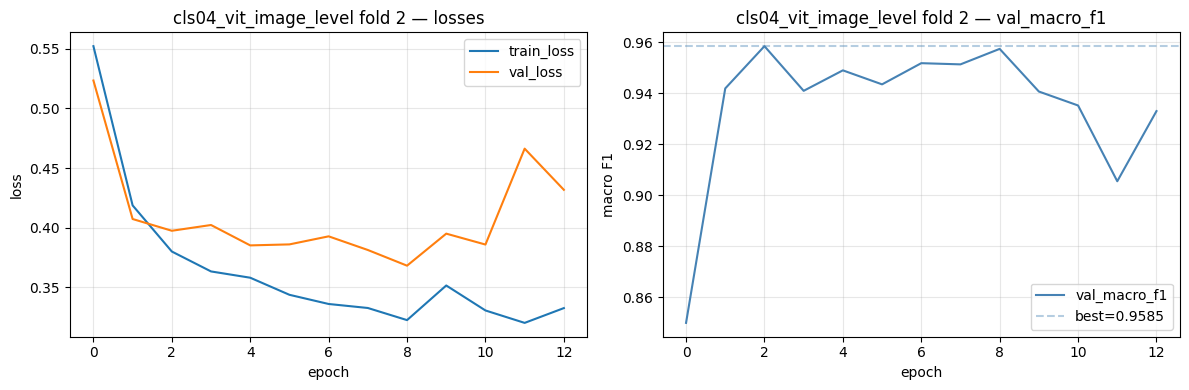

  saved /content/Senior_Project_local/outputs/figures/classification/figshare/cls04_vit_image_level/fold_2/history_fold_2.png


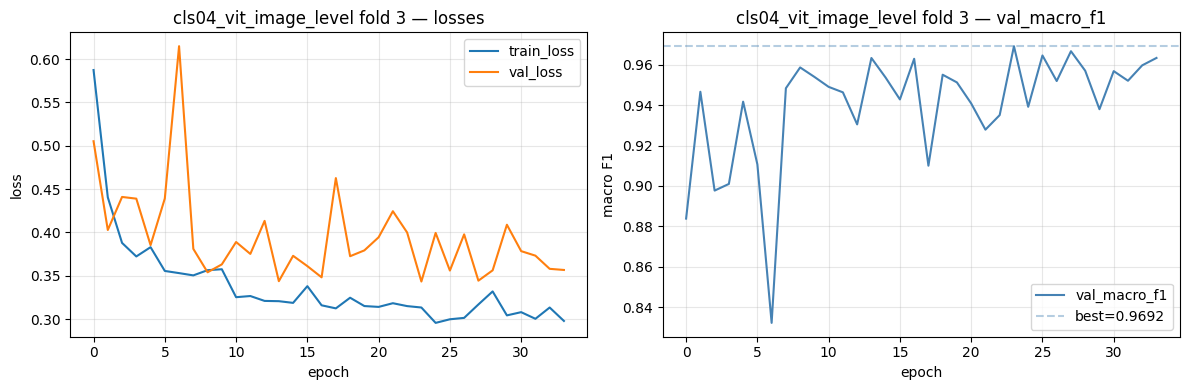

  saved /content/Senior_Project_local/outputs/figures/classification/figshare/cls04_vit_image_level/fold_3/history_fold_3.png


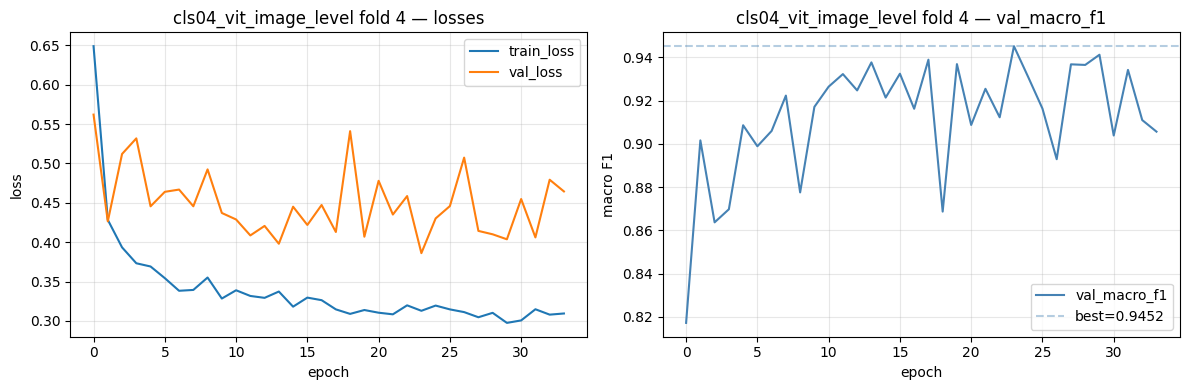

  saved /content/Senior_Project_local/outputs/figures/classification/figshare/cls04_vit_image_level/fold_4/history_fold_4.png


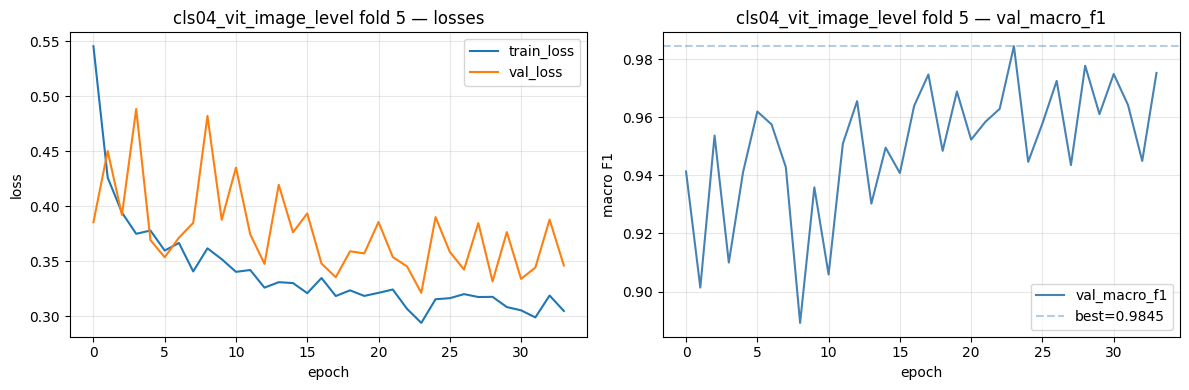

  saved /content/Senior_Project_local/outputs/figures/classification/figshare/cls04_vit_image_level/fold_5/history_fold_5.png


In [9]:
import matplotlib.pyplot as plt
from pathlib import Path

for fold, res in results.items():
    if 'error' in res:
        print(f'fold {fold}: skipped (failed during training)')
        continue
    h = res.get('history')
    if h is None or h.empty:
        print(f'fold {fold}: no metrics.csv found.')
        continue

    # metrics.csv is already consolidated (1 row per epoch)
    h_idx       = h.set_index('epoch')
    train_curve = h_idx['train_loss'].dropna()
    val_loss    = h_idx['val_loss'].dropna()
    val_f1      = h_idx['val_macro_f1'].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    if not train_curve.empty:
        axes[0].plot(train_curve.index, train_curve.values, label='train_loss')
    if not val_loss.empty:
        axes[0].plot(val_loss.index, val_loss.values, label='val_loss')
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
    axes[0].set_title(f'{EXPERIMENT["name"]} fold {fold} — losses')
    axes[0].grid(alpha=0.3)

    if not val_f1.empty:
        axes[1].plot(val_f1.index, val_f1.values, label='val_macro_f1', color='steelblue')
        axes[1].axhline(y=val_f1.max(), linestyle='--', alpha=0.4, color='steelblue',
                        label=f'best={val_f1.max():.4f}')
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('macro F1'); axes[1].legend()
    axes[1].set_title(f'{EXPERIMENT["name"]} fold {fold} — val_macro_f1')
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    paths = res['paths']
    fig_dir = Path(paths.get('figures', LOCAL_ROOT / 'outputs' / 'figures'
                             / EXPERIMENT['task'] / EXPERIMENT['dataset']
                             / EXPERIMENT['name'] / f'fold_{fold}'))
    fig_dir.mkdir(parents=True, exist_ok=True)
    out_png = fig_dir / f'history_fold_{fold}.png'
    fig.savefig(out_png, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'  saved {out_png}')

## Cell 9 — All-folds training curve overlay

/tmp/ipykernel_840/728872828.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pal = [cm.get_cmap('tab10')(i) for i in range(n)]


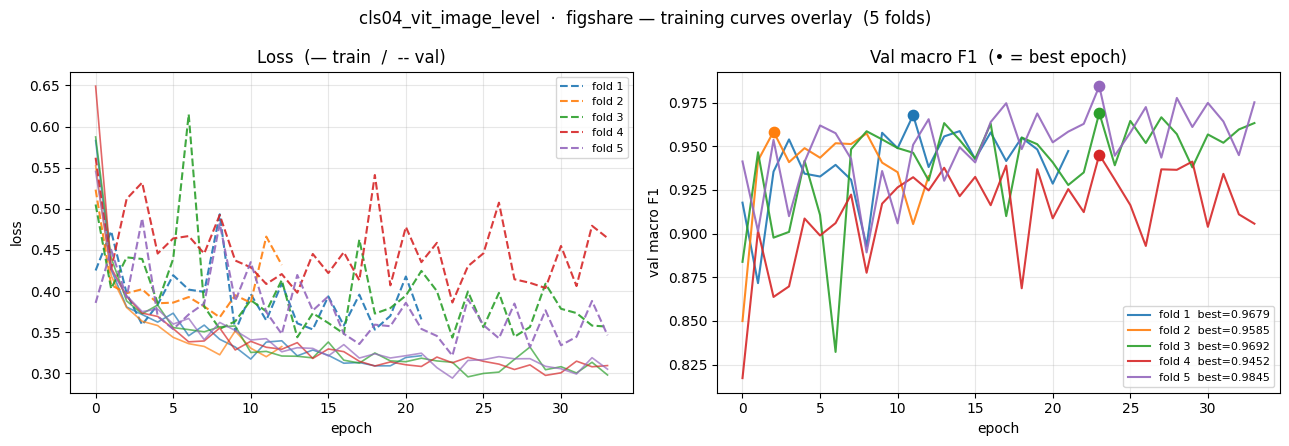

saved /content/Senior_Project_local/outputs/figures/classification/figshare/cls04_vit_image_level/training_curves_overlay.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

ok_results = {
    f: r for f, r in results.items()
    if 'error' not in r and r.get('history') is not None and not r['history'].empty
}

if not ok_results:
    print('No fold history available — run Cell 7 first.')
else:
    n   = len(ok_results)
    pal = [cm.get_cmap('tab10')(i) for i in range(n)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for (fold, res), color in zip(sorted(ok_results.items()), pal):
        # metrics.csv is already consolidated (1 row per epoch)
        h          = res['history'].set_index('epoch')
        train_loss = h['train_loss'].dropna()
        val_loss   = h['val_loss'].dropna()
        val_f1     = h['val_macro_f1'].dropna()

        if not train_loss.empty:
            axes[0].plot(train_loss.index, train_loss.values,
                         color=color, lw=1.2, alpha=0.7, ls='-')
        if not val_loss.empty:
            axes[0].plot(val_loss.index, val_loss.values,
                         color=color, lw=1.5, alpha=0.9, ls='--', label=f'fold {fold}')
        if not val_f1.empty:
            axes[1].plot(val_f1.index, val_f1.values,
                         color=color, lw=1.5, alpha=0.9,
                         label=f'fold {fold}  best={val_f1.max():.4f}')
            best_ep = int(val_f1.idxmax())
            axes[1].scatter([best_ep], [val_f1.max()], color=color, s=55, zorder=5)

    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
    axes[0].set_title('Loss  (— train  /  -- val)')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val macro F1')
    axes[1].set_title('Val macro F1  (• = best epoch)')
    axes[1].legend(fontsize=8, loc='lower right'); axes[1].grid(alpha=0.3)

    fig.suptitle(
        f"{EXPERIMENT['name']}  ·  {EXPERIMENT['dataset']} "
        f"— training curves overlay  ({n} folds)"
    )
    fig.tight_layout()

    fig_dir = (
        LOCAL_ROOT / 'outputs' / 'figures'
        / EXPERIMENT['task'] / EXPERIMENT['dataset'] / EXPERIMENT['name']
    )
    Path(fig_dir).mkdir(parents=True, exist_ok=True)
    out_png = fig_dir / 'training_curves_overlay.png'
    fig.savefig(out_png, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'saved {out_png}')

## Cell 10 — Training summary table

In [11]:
import pandas as pd
from pathlib import Path
from IPython.display import display

rows = []
for fold, res in results.items():
    if 'error' in res:
        rows.append({'experiment': EXPERIMENT['name'], 'fold': fold, 'status': 'FAILED', 'error': res['error']})
        continue
    rows.append({
        'experiment':           EXPERIMENT['name'],
        'dataset':              EXPERIMENT['dataset'],
        'split_scheme':         EXPERIMENT['split_scheme'],
        'fold':                 fold,
        'status':               'OK',
        'best_epoch':           res['best_epoch'],
        'best_val_macro_f1':    res['best_val_macro_f1'],
        'total_epochs_trained': res['total_epochs_trained'],
        'train_minutes':        round(res['train_seconds'] / 60.0, 2),
        'params_count':         res['params_count'],
        'peak_gpu_mem_mb':      res['peak_gpu_mem_mb'],
    })

summary_df = pd.DataFrame(rows)

exp_tables_dir = (
    LOCAL_ROOT / 'outputs' / 'tables'
    / EXPERIMENT['task'] / EXPERIMENT['dataset'] / EXPERIMENT['name']
)
exp_tables_dir.mkdir(parents=True, exist_ok=True)
out_csv = exp_tables_dir / f"{EXPERIMENT['name']}_train_summary.csv"
summary_df.to_csv(out_csv, index=False)
print(f'saved {out_csv}')

ok_df = summary_df[summary_df['status'] == 'OK']
fmt   = {'best_val_macro_f1': '{:.4f}', 'train_minutes': '{:.1f}', 'params_count': '{:,.0f}'}

display(summary_df.style.format(fmt, na_rep='—'))

if not ok_df.empty:
    vals = ok_df['best_val_macro_f1'].dropna()
    import numpy as np
    print(f"\nbest_val_macro_f1: {vals.mean():.4f} ± {vals.std(ddof=1):.4f}  "
          f"[min {vals.min():.4f}  max {vals.max():.4f}]")

saved /content/Senior_Project_local/outputs/tables/classification/figshare/cls04_vit_image_level/cls04_vit_image_level_train_summary.csv


,experiment,dataset,split_scheme,fold,status,best_epoch,best_val_macro_f1,total_epochs_trained,train_minutes,params_count,peak_gpu_mem_mb
0,cls04_vit_image_level,figshare,image_level,1,OK,11,0.9679,23,3.5,"21,666,819",938.615723
1,cls04_vit_image_level,figshare,image_level,2,OK,2,0.9585,14,2.1,"21,666,819",937.245605
2,cls04_vit_image_level,figshare,image_level,3,OK,23,0.9692,35,5.4,"21,666,819",940.713379
3,cls04_vit_image_level,figshare,image_level,4,OK,23,0.9452,35,5.4,"21,666,819",938.800293
4,cls04_vit_image_level,figshare,image_level,5,OK,23,0.9845,35,5.4,"21,666,819",940.713379



best_val_macro_f1: 0.9650 ± 0.0145  [min 0.9452  max 0.9845]


## Cell 11 — Sync to Drive

In [12]:
from src.notebook_setup import sync_outputs_to_drive

sync_outputs_to_drive(
    drive_root=DRIVE_ROOT, local_root=LOCAL_ROOT,
    task=EXPERIMENT['task'], dataset=EXPERIMENT['dataset'],
    experiment_name=EXPERIMENT['name'],
    categories=['checkpoints', 'logs', 'tables', 'figures'],
)
print('sync complete')

[sync_outputs_to_drive] synced: checkpoints, logs, tables, figures
sync complete


In [13]:
SYNC_OK = True   # set manually based on the sync cell above
if SYNC_OK:
    from google.colab import runtime
    print('Disconnecting runtime in 3 seconds...')
    import time; time.sleep(3)
    runtime.unassign()
else:
    print('SYNC_OK is False — staying connected.')

Disconnecting runtime in 3 seconds...
